# Cross-Sectional De-Time Factor Selection


This notebook asks whether De-Time factor candidates improve a cross-sectional rotation after costs. It ranks a fixed US large-cap universe using walk-forward trend, residual, cycle, and reconstruction-error features.

The output is a baseline comparison, not a standalone success claim. Read the tables for the sample window, parameters, after-cost metrics, turnover, and whether the result clears equal-weight, benchmark, momentum-only, and random top-N checks.

**Default decomposition:** `ROBUST_STL` with a 63-trading-day period, computed walk-forward where signals are backtested.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from examples.quant_trading.data import fetch_yahoo_prices, fetch_yahoo_ohlcv, data_audit_report, DEFAULT_UNIVERSES
from examples.quant_trading.features import decompose_one_series, walkforward_decompose, build_feature_table
from examples.quant_trading.signals import (
    trend_pullback_signals,
    residual_mean_reversion_signals,
    turtle_donchian_signals,
    pair_trading_weights,
    cross_sectional_rotation_weights,
    residual_stress_filter,
)
from examples.quant_trading.backtest import backtest_weights, backtest_long_short_signals, summarize_returns

DATA_CACHE = Path("examples/quant_trading/data/cache")
QUANT_METHOD = "ROBUST_STL"
QUANT_PERIOD = 63


In [2]:
universe = DEFAULT_UNIVERSES["us_large_cap"][:10]
start_date = "2017-01-01"
top_n = 3
fee_bps = 1.0
slippage_bps = 3.0

prices = fetch_yahoo_prices(universe, start=start_date, cache_dir=DATA_CACHE)
features = walkforward_decompose(prices, method=QUANT_METHOD, period=QUANT_PERIOD, train_window=252, step=21)
weights = cross_sectional_rotation_weights(prices, features, top_n=top_n, vol_target=0.15)
result = backtest_weights(prices, weights, fee_bps=fee_bps, slippage_bps=slippage_bps)

def equal_weight_panel(frame):
    return pd.DataFrame(1.0 / frame.shape[1], index=frame.index, columns=frame.columns)

def momentum_topn_weights(frame, lookback=63, top_n=3):
    score = frame.pct_change(lookback)
    out = pd.DataFrame(0.0, index=frame.index, columns=frame.columns)
    for dt, row in score.iterrows():
        valid = row.dropna()
        if valid.empty:
            continue
        names = valid.nlargest(min(top_n, len(valid))).index
        out.loc[dt, names] = 1.0 / len(names)
    return out

def random_topn_weights(frame, top_n=3, rebalance=21, seed=42):
    rng = np.random.default_rng(seed)
    out = pd.DataFrame(0.0, index=frame.index, columns=frame.columns)
    current = pd.Series(0.0, index=frame.columns)
    for i, dt in enumerate(frame.index):
        if i >= 252 and i % rebalance == 0:
            valid = frame.loc[:dt].dropna(axis=1, how="all").columns.to_list()
            chosen = rng.choice(valid, size=min(top_n, len(valid)), replace=False) if valid else []
            current = pd.Series(0.0, index=frame.columns)
            if len(chosen):
                current.loc[chosen] = 1.0 / len(chosen)
        out.loc[dt] = current
    return out

baseline_weights = {
    "equal_weight_same_universe": equal_weight_panel(prices),
    "momentum_top3_same_universe": momentum_topn_weights(prices, top_n=top_n),
    "random_top3_same_universe": random_topn_weights(prices, top_n=top_n),
}
baseline_results = {
    name: backtest_weights(prices, w, fee_bps=fee_bps, slippage_bps=slippage_bps)
    for name, w in baseline_weights.items()
}

benchmark_prices = fetch_yahoo_prices(["SPY", "QQQ"], start=start_date, cache_dir=DATA_CACHE)
benchmark_weights = equal_weight_panel(benchmark_prices)
benchmark_result = backtest_weights(benchmark_prices, benchmark_weights, fee_bps=fee_bps, slippage_bps=slippage_bps)
baseline_results["SPY_QQQ_equal_weight"] = benchmark_result

comparison = pd.DataFrame({"detime_rotation": result.stats, **{name: bt.stats for name, bt in baseline_results.items()}}).T
comparison["sample_start"] = str(prices.index.min().date())
comparison["sample_end"] = str(prices.index.max().date())
comparison["top_n"] = top_n
comparison["fee_bps"] = fee_bps
comparison["slippage_bps"] = slippage_bps
metric_cols = ["total_return", "cagr", "volatility", "sharpe", "max_drawdown", "average_turnover", "fee_bps", "slippage_bps", "sample_start", "sample_end", "top_n"]
comparison[metric_cols]


,total_return,cagr,volatility,sharpe,max_drawdown,average_turnover,fee_bps,slippage_bps,sample_start,sample_end,top_n
detime_rotation,3.726616,0.180397,0.158956,1.123136,-0.216619,0.040977,1.0,3.0,2017-01-03,2026-05-22,3
equal_weight_same_universe,11.676372,0.311528,0.242462,1.240710,-0.347250,0.000000,1.0,3.0,2017-01-03,2026-05-22,3
momentum_top3_same_universe,25.735403,0.420312,0.304583,1.305883,-0.442538,0.178672,1.0,3.0,2017-01-03,2026-05-22,3
random_top3_same_universe,9.526774,0.285761,0.274255,1.054014,-0.399496,0.060593,1.0,3.0,2017-01-03,2026-05-22,3
SPY_QQQ_equal_weight,3.993285,0.187336,0.201920,0.951881,-0.308583,0.000000,1.0,3.0,2017-01-03,2026-05-22,3


In [3]:
baseline_sharpe = comparison.drop(index="detime_rotation")["sharpe"].max()
baseline_cagr = comparison.drop(index="detime_rotation")["cagr"].max()
result_boundary = pd.DataFrame([{
    "research_question": "Do De-Time factor candidates beat simple baselines after costs?",
    "detime_sharpe": comparison.loc["detime_rotation", "sharpe"],
    "best_baseline_sharpe": baseline_sharpe,
    "detime_cagr": comparison.loc["detime_rotation", "cagr"],
    "best_baseline_cagr": baseline_cagr,
    "status": "confirming" if (comparison.loc["detime_rotation", "sharpe"] > baseline_sharpe and comparison.loc["detime_rotation", "cagr"] > baseline_cagr) else "inconclusive_or_failed",
    "boundary": "No factor claim unless the strategy beats equal-weight, benchmark, momentum-only, and random top-N baselines after costs across walk-forward folds.",
}])
display(result_boundary)
weights.tail(10)


,research_question,detime_sharpe,best_baseline_sharpe,detime_cagr,best_baseline_cagr,status,boundary
0,Do De-Time factor candidates beat simple basel...,1.123136,1.305883,0.180397,0.420312,inconclusive_or_failed,No factor claim unless the strategy beats equa...


,AAPL,MSFT,NVDA,AMZN,META,GOOGL,TSLA,JPM,XOM,UNH
Date,,,,,,,,,,
2026-05-11,0.307970,0.0,0.307970,0.30797,0.0,0.0,0.0,0.000000,0.0,0.0
2026-05-12,0.312143,0.0,0.312143,0.00000,0.0,0.0,0.0,0.312143,0.0,0.0
2026-05-13,0.311622,0.0,0.311622,0.00000,0.0,0.0,0.0,0.311622,0.0,0.0
2026-05-14,0.314277,0.0,0.314277,0.00000,0.0,0.0,0.0,0.314277,0.0,0.0
2026-05-15,0.307119,0.0,0.307119,0.00000,0.0,0.0,0.0,0.307119,0.0,0.0
2026-05-18,0.306632,0.0,0.306632,0.00000,0.0,0.0,0.0,0.306632,0.0,0.0
2026-05-19,0.305367,0.0,0.305367,0.00000,0.0,0.0,0.0,0.305367,0.0,0.0
2026-05-20,0.301766,0.0,0.301766,0.00000,0.0,0.0,0.0,0.301766,0.0,0.0
2026-05-21,0.303194,0.0,0.303194,0.00000,0.0,0.0,0.0,0.303194,0.0,0.0


## Decomposition-to-rank bridge

The rotation score is built from four decomposition-derived ingredients. This table shows the latest cross-section so readers can see whether the target weights come from trend strength, residual pullback, cycle tilt, or a reconstruction penalty.

In [4]:
score_date = weights.abs().sum(axis=1).replace(0.0, np.nan).dropna().index[-1]
trend_rank = features["trend_slope"].loc[score_date].rank(pct=True)
pullback_rank = (-features["residual_z"].loc[score_date]).rank(pct=True)
cycle_rank = features["season_slope"].loc[score_date].rank(pct=True)
noise_penalty = features["reconstruction_error"].loc[score_date].rank(pct=True)
score_parts = pd.DataFrame({
    "trend_rank": trend_rank,
    "residual_pullback_rank": pullback_rank,
    "cycle_rank": cycle_rank,
    "reconstruction_penalty": noise_penalty,
})
score_parts["final_score"] = score_parts["trend_rank"] + score_parts["residual_pullback_rank"] + score_parts["cycle_rank"] - 0.25 * score_parts["reconstruction_penalty"]
score_parts["target_weight"] = weights.loc[score_date]
score_parts.sort_values("final_score", ascending=False).style.format("{:.3f}")

,trend_rank,residual_pullback_rank,cycle_rank,reconstruction_penalty,final_score,target_weight
AAPL,0.700,0.800,0.700,0.500,2.075,0.311
NVDA,0.800,0.500,0.800,0.500,1.975,0.311
UNH,0.300,0.700,1.000,0.500,1.875,0.000
JPM,0.600,1.000,0.400,0.500,1.875,0.311
XOM,1.000,0.300,0.600,0.500,1.775,0.000
META,0.400,0.900,0.300,0.500,1.475,0.000
MSFT,0.200,0.600,0.500,0.500,1.175,0.000
GOOGL,0.900,0.400,0.100,1.000,1.150,0.000
TSLA,0.100,0.100,0.900,0.500,0.975,0.000
AMZN,0.500,0.200,0.200,0.500,0.775,0.000


## Visualization: score ingredients and selected asset decomposition

The bar chart shows which component ranks support the latest allocation. The lower panels then inspect the highest-weight asset so the decomposition behind the allocation can be checked before interpreting the backtest.

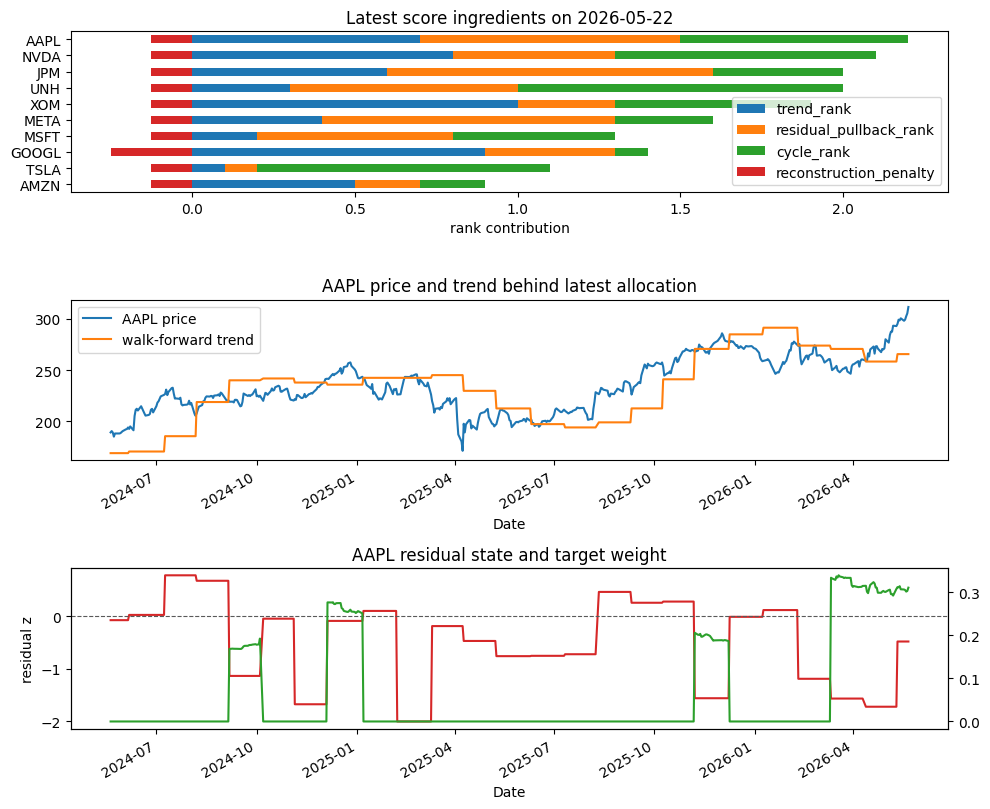

In [5]:
plot_parts = score_parts.sort_values("final_score").tail(10)
stacked = plot_parts[["trend_rank", "residual_pullback_rank", "cycle_rank"]].copy()
stacked["reconstruction_penalty"] = -0.25 * plot_parts["reconstruction_penalty"]
selected_asset = score_parts["target_weight"].idxmax() if score_parts["target_weight"].max() > 0 else score_parts["final_score"].idxmax()
window = prices.index[-504:]
trend_level = np.exp(features["trend"][selected_asset]).reindex(window)
residual_z = features["residual_z"][selected_asset].reindex(window)
asset_weight = weights[selected_asset].reindex(window)

fig, axes = plt.subplots(3, 1, figsize=(10, 8.2))
stacked.plot(kind="barh", stacked=True, ax=axes[0], title=f"Latest score ingredients on {score_date.date()}")
axes[0].set_xlabel("rank contribution")
prices[selected_asset].reindex(window).plot(ax=axes[1], color="tab:blue", label=f"{selected_asset} price")
trend_level.plot(ax=axes[1], color="tab:orange", label="walk-forward trend")
axes[1].set_title(f"{selected_asset} price and trend behind latest allocation")
axes[1].legend(loc="best")
residual_z.plot(ax=axes[2], color="tab:red", label="residual z-score")
asset_weight.plot(ax=axes[2], color="tab:green", secondary_y=True, label="target weight")
axes[2].axhline(0.0, color="0.35", linestyle="--", linewidth=0.8)
axes[2].set_title(f"{selected_asset} residual state and target weight")
axes[2].set_ylabel("residual z")
plt.tight_layout()
plt.show()

## Visualization: cross-sectional allocation snapshot

The left axis shows the latest target weight by ticker. The right panel shows how those weights changed over roughly the last trading year. Concentration or rapid allocation churn is a warning sign because a strong equity curve can come from one mega-cap or one short regime.


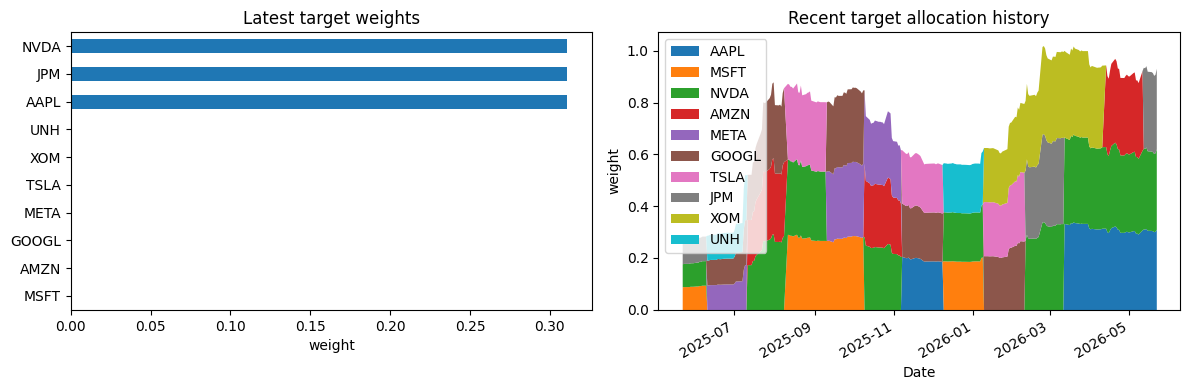

In [6]:
latest_weights = weights.dropna(how="all").tail(1).T.iloc[:, 0].sort_values()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
latest_weights.plot(kind="barh", ax=axes[0], title="Latest target weights")
weights.tail(252).plot.area(ax=axes[1], title="Recent target allocation history", linewidth=0.0)
axes[0].set_xlabel("weight")
axes[1].set_ylabel("weight")
plt.tight_layout()
plt.show()


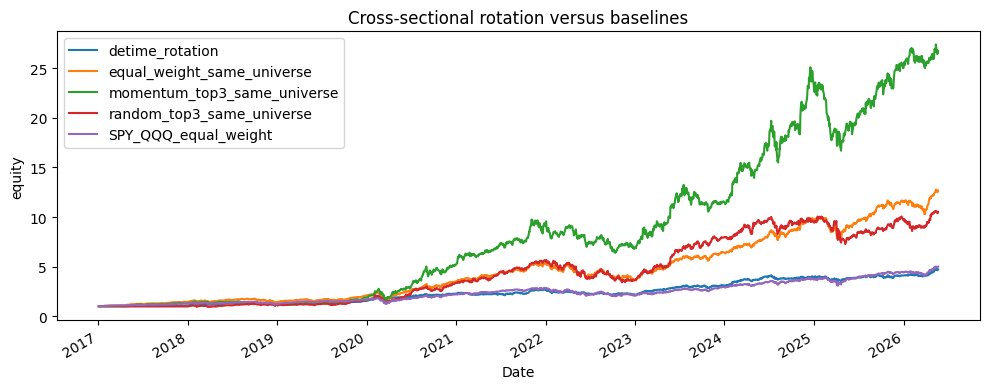

In [7]:
equity_curves = pd.concat(
    {"detime_rotation": result.equity, **{name: bt.equity for name, bt in baseline_results.items()}},
    axis=1,
).dropna(how="all")
equity_curves.plot(figsize=(10, 4), title="Cross-sectional rotation versus baselines")
plt.ylabel("equity")
plt.tight_layout()
plt.show()


## Visualization: rotation drawdown

The drawdown panel compares risk across the same after-cost runs. A De-Time result that only improves return while taking much deeper drawdowns should be treated as inconclusive until the risk model is tightened.


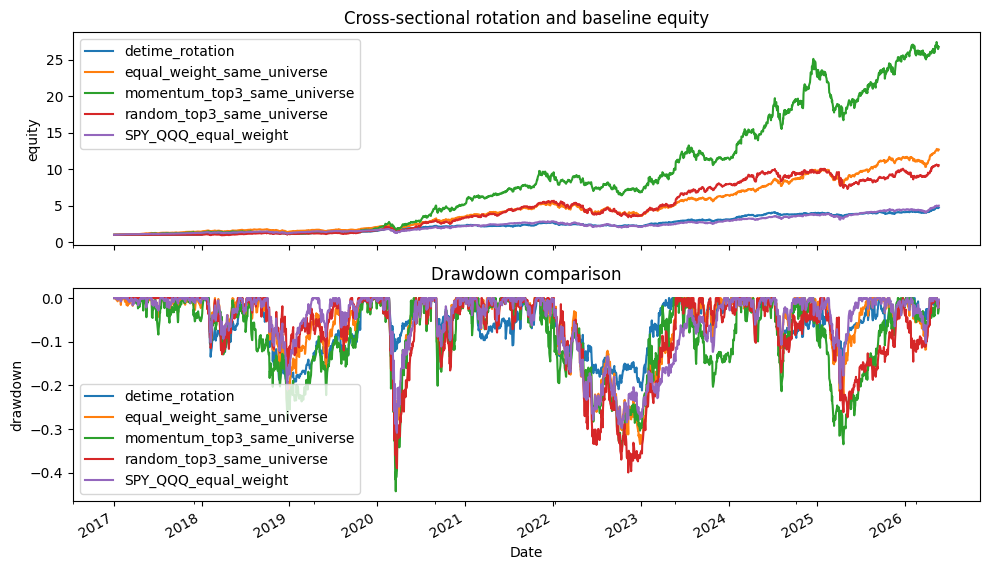

In [8]:
drawdowns = equity_curves / equity_curves.cummax() - 1.0
fig, axes = plt.subplots(2, 1, figsize=(10, 5.8), sharex=True)
equity_curves.plot(ax=axes[0], title="Cross-sectional rotation and baseline equity")
drawdowns.plot(ax=axes[1], title="Drawdown comparison")
axes[0].set_ylabel("equity")
axes[1].set_ylabel("drawdown")
plt.tight_layout()
plt.show()


## Interpretation boundary

This sample uses a current US mega-cap universe from a public data source. A strong result can reflect survivorship, mega-cap concentration, one market regime, or parameter fit. Treat the notebook as a validation template unless the result clears the baseline set in independent walk-forward folds.